# Water Rights Restored to the Gila River

The impacts of irrigation on vegetation health in the Gila River Valley

Elsa Culler  
Nate Quarderer  
2025-07-09

# STEP 0: Set up

To get started on this notebook, you’ll need to restore any variables
from previous notebooks to your workspace. To save time and memory, make
sure to specify which variables you want to load.

In [1]:
%store -r

You will also need to import any libraries you are using in this
notebook, since they won’t carry over from the previous notebook:

In [2]:
# Import libraries

## Import libraries

We’ll need some Python libraries to complete this workflow.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It: Import necessary libraries</div></div><div class="callout-body-container callout-body"><p>In the cell below, making sure to keep the packages in order, add
packages for:</p>
<ul>
<li>Working with DataFrames</li>
<li>Working with GeoDataFrames</li>
<li>Making interactive plots of tabular and vector data</li>
</ul></div></div>

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-respond"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Reflect and Respond</div></div><div class="callout-body-container callout-body"><p>What are we using the rest of these packages for? See if you can
figure it out as you complete the notebook.</p></div></div>

In [19]:
import json
from glob import glob

import earthpy
import earthpy.api.appeears as eaapp
import hvplot.xarray
import rioxarray as rxr
import xarray as xr

import pandas as pd
import geopandas as gpd
import hvplot.pandas

import osmnx as ox
import getpass
import time

## Download sample data

In this analysis, you’ll need to download multiple data files to your
computer rather than streaming them from the web. You’ll need to set up
a folder for the files, and while you’re at it download the sample data
there.

> **GOTCHA ALERT!**
>
> A lot of times in Python we say “directory” to mean a “folder” on your
> computer. The two words mean the same thing in this context.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>In the cell below, replace ‘Project Name’ with ‘<span
data-__quarto_custom="true" data-__quarto_custom_type="Shortcode"
data-__quarto_custom_context="Inline"
data-__quarto_custom_id="3"></span> and ’my-data-folder’ with a
<strong>descriptive</strong> directory name.</p></div></div>

In [4]:
project = earthpy.Project(
    'Tubarjal Valley Saudi Arabia Irrigation', dirname='irrigation_dr')
project.get_data()


**Final Configuration Loaded:**
{}
Found 'data_home' in environment variables.
🔄 Fetching metadata for article 29521241...
✅ Found 2 files for download.
[('https://ndownloader.figshare.com/files/56526608', 'tubarjal-ndvi', 'zip'), ('https://ndownloader.figshare.com/files/56526611', 'tubarjal-valley', 'zip')]
tubarjal-ndvi
Extracted output to /workspaces/data/irrigation_dr/tubarjal-ndvi
[PosixPath('/workspaces/data/irrigation_dr/tubarjal-ndvi')]
tubarjal-valley
Extracted output to /workspaces/data/irrigation_dr/tubarjal-valley
[PosixPath('/workspaces/data/irrigation_dr/tubarjal-ndvi'), PosixPath('/workspaces/data/irrigation_dr/tubarjal-valley')]


<Axes: >

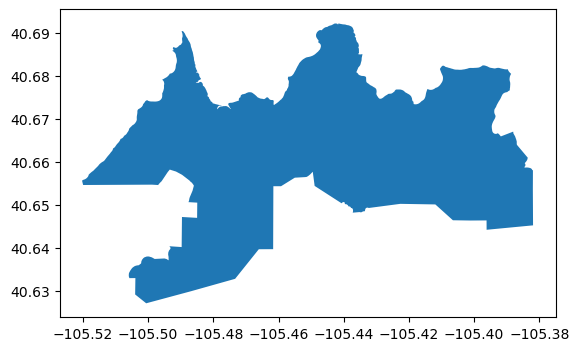

In [8]:
# get sample data for Poudre Wilderness

# first, get wilderness boundary polygon from OSM
place_name = "Cache la Poudre Wilderness"

tags = {
    "boundary": "protected_area", "operator": "United States Forest Service"
}

poudre_boundary_gdf = ox.features_from_place(place_name, tags=tags)

poudre_boundary_gdf.plot()

In [ ]:
# see what CRS this poly is in.. bc apparently the NASA API is picky 

poudre_boundary_gdf.crs

# see that it is EPSG:4326

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
# Create a project directory in the system data folder
poudre_project = earthpy.project.Project(
    dirname='poudre_dir')
poudre_project.project_dir


**Final Configuration Loaded:**
{}
Found 'data_home' in environment variables.


PosixPath('/workspaces/data/poudre_dir')

In [14]:
# save boundary
# Create path for boundary
poudre_boundary_path = poudre_project.project_dir / 'poudre_dir'
# Can't overwrite existing files, which seems to be an intractable GDAL issue
if poudre_boundary_path.exists():
    shutil.rmtree(poudre_boundary_path)

# Write OSM result to shapefile
poudre_boundary_gdf.to_file(poudre_boundary_path)

/tmp/ipykernel_608/2156808944.py:9: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  poudre_boundary_gdf.to_file(poudre_boundary_path)
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'operator:short' to 'operator_s'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'operator:type' to 'operator_t'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'operator:wikidata' to 'operator_w'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'protect_class' to 'protect_cl'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'protected_area' to 'protected_'
  ogr_write(
/opt/conda/lib/python3.11/site-packa

In [29]:
# get NDVI data from NASA API

# Define request parameters
project_name = "Poudre_NDVI"
product_name = "MOD13Q1.061"  # MODIS/Terra Vegetation Indices 16-Day L3 Global 250m
layer_name = "_250m_16_days_NDVI"          # Normalized Difference Vegetation Index
start_day_month = "01-01" # Start of the year (Day-Month)
end_day_month = "12-31"   # End of the year (Day-Month)
start_year = 2017
end_year = 2024
output_format = "geotiff"    # Output format (e.g., "geotiff", "netcdf4")
output_projection = "geographic" # CRS for the output (e.g., "geographic" or a specific EPSG code)
request_name = "Poudre_Boundary_MODIS_NDVI_2017_2024_AppearsDownloader"
output_dir = "./poudre_dir"

In [ ]:


ndvi_downloader = eaapp.AppeearsDownloader(
    
        # The 'project' parameter defines the project name for your request on AppEEARS
        project=project_name, 
        product=product_name,
        layer=layer_name,
        start_date=start_day_month, # Use day-month format for recurring
        end_date=end_day_month,     # Use day-month format for recurring
        recurring=True,             # Set to True for year_range functionality
        year_range=[start_year, end_year],
        polygon=poudre_boundary_gdf, # Pass the GeoDataFrame directly
    )

ndvi_downloader.download_files(cache=True)

AttributeError: 'str' object has no attribute 'project_dir'

# STEP -1: Wrap up

Don’t forget to store your variables so you can use them in other
notebooks! Replace `var1` and `var2` with the variable you want to save,
separated by spaces.

In [5]:
%store project

Stored 'project' (Project)


Finally, be sure to `Restart` and `Run all` to make sure your notebook
works all the way through!